In [1]:
##Load the base configuration (Engine Model)
import sys
sys.path.append(r'C:\Users\Public\Documents\CIF\orchestrations\Python')
import cif_orchestration_base
import time

#Set the IP address and port of the CIF manager on the target
server_ip = "192.168.1.222"
manager_port = "15882"

#Configuration for plugins including channel links  
engine_model = cif_orchestration_base.plugin("engine_model", "Model_Interface_Plugin", "", "")
engine_model_config2 = '{"Model Path":"Engine Demo 64.so"}'


#Create connection to the CIF manager
cif_manager = cif_orchestration_base.cif_manager(server_ip, manager_port)

#Business logic (Load plugins, link channel, configure plugins, change state, etc)
cif_manager.load(engine_model)
engine_model.update_config(engine_model_config2)
engine_model.run(wait_running=False)
print("-------------- Engine Model Loaded --------------")

-------------- Engine Model Loaded --------------


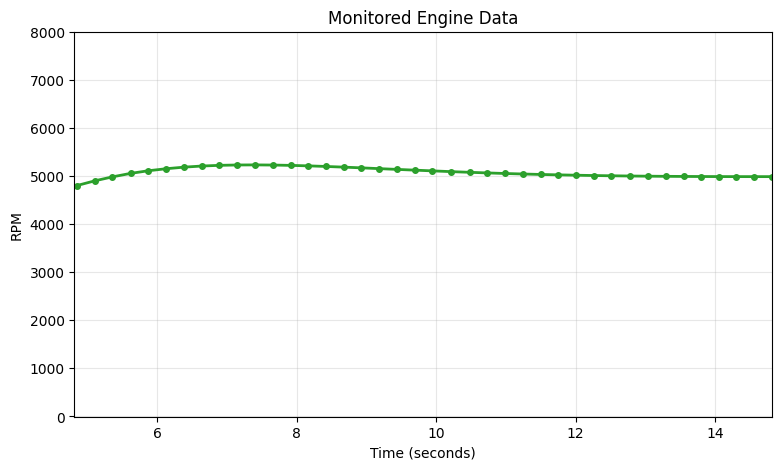

In [2]:
## Run example test setting values and monitoring the response of the system
# import sys
# sys.path.append(r'C:\Users\Public\Documents\CIF\orchestrations\Python')
# import cif_orchestration_base
import time
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output

#Configuration for plugins including channel links  
tag_monitor = cif_orchestration_base.plugin("tagmon", "Tag_Monitor_Plugin", "", "")

# #Business logic (Load plugins, link channel, configure plugins, change state, etc)
cif_manager.load(tag_monitor)
tag_monitor.run(wait_running=True)
engine_model.force_channel_double("engine_model.command_EngineOn", True, 1.0)
engine_model.force_channel_double("engine_model.command_RPM", True, 5000.0)

#Example test logic (in this example display for 15 seconds)
# --- CONFIGURATION ---
window_size = 10      # How many seconds of data to show at once
update_interval = 0.2 # How often to refresh (lower = smoother)
total_duration = 15   # Total run time
# ---------------------

x_data = []
y_data = []

fig, ax = plt.subplots(figsize=(9, 5))
start_time = time.time()

while (time.time() - start_time) < total_duration:
    current_time = time.time() - start_time
    new_val = tag_monitor.monitor_tag(["engine_model.RPM"])
    
    x_data.append(current_time)
    y_data.append(new_val.tag_values[0])
    
    ax.clear()
    ax.plot(x_data, y_data, color='#2ca02c', linewidth=2, marker='o', markersize=4)
    
    # --- SCROLLING LOGIC ---
    # If we haven't reached the window size yet, show 0 to window_size
    # Once we pass it, shift the window to follow the latest point
    if current_time < window_size:
        ax.set_xlim(0, window_size)
    else:
        ax.set_xlim(current_time - window_size, current_time)
    
    # Formatting
    ax.set_ylim(-5, 8000)
    ax.set_title("Monitored Engine Data")
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("RPM")
    ax.grid(True, alpha=0.3)
    
    clear_output(wait=True)
    display(fig)
    time.sleep(update_interval)

plt.close()

In [3]:
## Clear values set for test
engine_model.force_channel_double("engine_model.command_RPM", True, 0.0)
# engine_model.force_channel_double("engine_model.command_EngineOn", True, 0.0)
engine_model.force_channel_double("engine_model.command_RPM", False, 0.0)
engine_model.force_channel_double("engine_model.command_EngineOn", False, 0.0)
print("Model cleared")

Model cleared
